In [1]:
from pytools4scarf import dataloader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dfs, lts = {}, {}

dfs["r038"], lts["r038"] = dataloader.load_lh5_run(
    ["ch001/hit", "ch002/hit"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/data_cleaning.yaml",
    "hit",
    "sp01",
    "p00",
    "r038",
    "phy",
    ["ch001", "ch002"],    
)

In [3]:
dfs["r059"], lts["r059"] = dataloader.load_lh5_run(
    ["ch001/hit", "ch002/hit"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/data_cleaning.yaml",
    "hit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch001", "ch002"],
)

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x7f5b3df1e020>
Traceback (most recent call last):
  File "/mnt/atlas02/users/leoli/.conda/envs/scarf7/lib/python3.13/weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):
KeyboardInterrupt: 


In [9]:
dfs["r057"], lts["r057"] = dataloader.load_lh5_run(
    ["ch001/hit", "ch002/hit"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/data_cleaning.yaml",
    "hit",
    "sp01",
    "p05",
    "r057",
    "cal",
    ["ch001", "ch002"],
)

In [4]:
sec_to_day = 1 / (60 * 60 * 24)

Text(0, 0.5, 'Count rate (1 / day)')

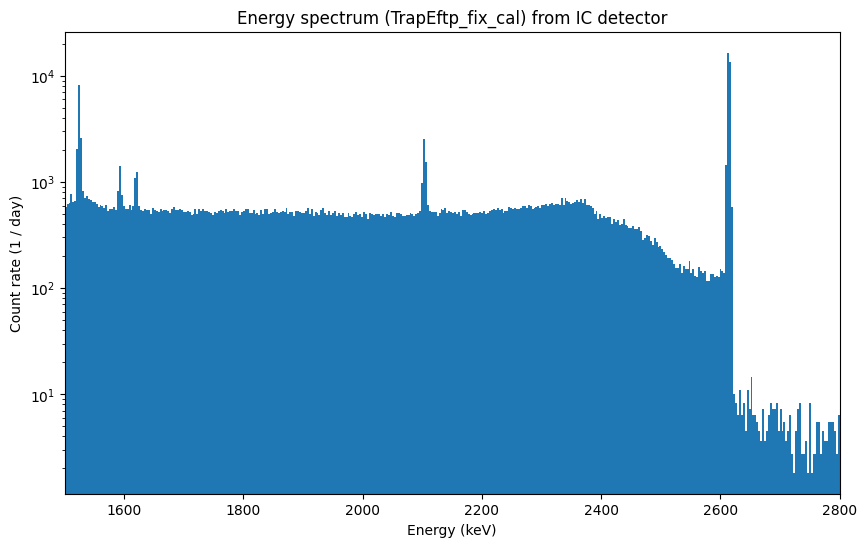

In [10]:
# df_bg = dfs["r038"]["ch002"]
# mask_bg = df_bg.is_valid_waveform & df_bg.A_max_o_E_High_Side_Cut
df_phy = dfs["r057"]["ch002"]
mask_phy = df_phy.is_valid_waveform & df_phy.A_max_o_E_High_Side_Cut
xrange = (1500, 2800)
nbins = 400
fig, ax =plt.subplots(figsize=(10, 6))
# vals, edges = np.histogram(df_bg[mask_bg]["trapEftp_fix_cal"], bins=nbins, range=xrange)
vals_2, edges_2 = np.histogram(df_phy[mask_phy]["trapEftp_fix_cal"], bins=nbins, range=xrange,)
# vals = vals/lts["r038"]/sec_to_day
vals_2 = vals_2/lts["r057"]/sec_to_day
ax.stairs(vals_2, edges_2, fill=True,alpha=1)
# ax.stairs(vals, edges, fill=True, color="gray", alpha=1)
# plt.axvline(x=1839, color="red", linestyle="--", linewidth=2)
# plt.axvline(x=2239, color="red", linestyle="--", linewidth=2)
ax.set_xlabel("Energy (keV)")
ax.set_xlim([1500,2800])
ax.set_yscale("log")
ax.set_title(r"Energy spectrum (TrapEftp_fix_cal) from IC detector")
# plt.legend([r"After $^{42}$Ar injection", r"Before $^{42}$Ar injection",r"Region of Interest (1839-2239 keV)"])
ax.set_ylabel("Count rate (1 / day)")